# Semantic Search Chatbot Notebook
This notebook contains the step-by-step implementation of the NLP Q&A system.

# Data Download & Preprocessing (SQuAD v1.1)

This section downloads the SQuAD v1.1 dataset, extracts contexts as documents, cleans them, chunks them into token-aware segments, and saves:
- Full processed chunks to `data/processed/` (ignored by git),
- Small samples to `data/sample/` (committed) for demo & CI.

In [ ]:
import os
import json
import math
import uuid
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer

# --- Paths ---
ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[1]
# If paths look wrong in VS Code, fallback to repo root manually:
REPO = REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = REPO / "data" / "raw"
DATA_PROCESSED = REPO / "data" / "processed"
DATA_SAMPLE = REPO / "data" / "sample"

for p in [DATA_RAW, DATA_PROCESSED, DATA_SAMPLE]:
    p.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO)
print("Raw:", DATA_RAW)
print("Processed:", DATA_PROCESSED)
print("Sample:", DATA_SAMPLE)


c:\Users\pc\Documents\GitHub\Semantic-search-chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo: c:\Users\pc\Documents\GitHub
Raw: c:\Users\pc\Documents\GitHub\data\raw
Processed: c:\Users\pc\Documents\GitHub\data\processed
Sample: c:\Users\pc\Documents\GitHub\data\sample


In [2]:
# Download SQuAD v1.1 (train/dev)
dataset = load_dataset("squad")
train = dataset["train"]
dev = dataset["validation"]

print(train)
print(dev)
print("Example item keys:", train[0].keys())

c:\Users\pc\Documents\GitHub\Semantic-search-chatbot\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\datasets--squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular H

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 87599
})
Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 10570
})
Example item keys: dict_keys(['id', 'title', 'context', 'question', 'answers'])


In [3]:
def clean_text(txt: str) -> str:
    # lightweight cleaning; keep it minimal to avoid losing meaning
    txt = txt.replace("\xa0", " ").replace("\t", " ").replace("\r", " ")
    txt = " ".join(txt.split())  # normalize whitespace
    return txt.strip()

# Extract unique contexts from train + dev
all_contexts = [clean_text(x["context"]) for x in train] + [clean_text(x["context"]) for x in dev]
unique_contexts = list(dict.fromkeys(all_contexts))  # preserve order, remove duplicates
len_unique = len(unique_contexts)
len_all = len(all_contexts)

print(f"All contexts: {len_all:,} | Unique contexts: {len_unique:,}")
print("Sample context:", unique_contexts[0][:300], "...")


All contexts: 98,169 | Unique contexts: 20,958
Sample context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is  ...


In [4]:
# Use the same tokenizer family you’ll use for embeddings later
# MiniLM works well on CPU and is small.
TOKENIZER_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)

MAX_TOKENS = 240
STRIDE = 60  # overlap

def chunk_by_tokens(text: str, max_tokens: int = MAX_TOKENS, stride: int = STRIDE):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        sub = tokens[start:end]
        chunk_text = tokenizer.decode(sub, skip_special_tokens=True)
        chunks.append(chunk_text)
        if end == len(tokens):
            break
        start = max(0, end - stride)
    return chunks

# quick sanity test
test_chunks = chunk_by_tokens(unique_contexts[0])
len(test_chunks), sum(len(tokenizer.encode(c, add_special_tokens=False)) for c in test_chunks)


c:\Users\pc\Documents\GitHub\Semantic-search-chatbot\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


(1, 158)

In [5]:
def build_chunk_records(docs: list[str]):
    records = []
    for doc_id, doc in enumerate(docs):
        chunks = chunk_by_tokens(doc)
        for i, ch in enumerate(chunks):
            rec = {
                "doc_uuid": f"doc-{doc_id:06d}",
                "chunk_id": i,
                "text": ch,
                "n_tokens": len(tokenizer.encode(ch, add_special_tokens=False)),
                "source": "squad_v1.1"
            }
            records.append(rec)
    return records

chunk_records = build_chunk_records(unique_contexts)
len(chunk_records), chunk_records[0]


Token indices sequence length is longer than the specified maximum sequence length for this model (718 > 512). Running this sequence through the model will result in indexing errors


(22987,
 {'doc_uuid': 'doc-000000',
  'chunk_id': 0,
  'text': 'architecturally, the school has a catholic character. atop the main building \' s gold dome is a golden statue of the virgin mary. immediately in front of the main building and facing it, is a copper statue of christ with arms upraised with the legend " venite ad me omnes ". next to the main building is the basilica of the sacred heart. immediately behind the basilica is the grotto, a marian place of prayer and reflection. it is a replica of the grotto at lourdes, france where the virgin mary reputedly appeared to saint bernadette soubirous in 1858. at the end of the main drive ( and in a direct line that connects through 3 statues and the gold dome ), is a simple, modern stone statue of mary.',
  'n_tokens': 158,
  'source': 'squad_v1.1'})

In [7]:
# FULL processed dump (ignored by git)
full_jsonl = DATA_PROCESSED / "squad_chunks.jsonl"
with full_jsonl.open("w", encoding="utf-8") as f:
    for rec in chunk_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

# SMALL sample for repo/demo (commit this!)
sample_n = 200  # small but useful
sample_jsonl = DATA_SAMPLE / "squad_chunks_sample.jsonl"
with sample_jsonl.open("w", encoding="utf-8") as f:
    for rec in chunk_records[:sample_n]:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved:", full_jsonl)
print("Saved sample:", sample_jsonl, "(", sample_n, "records )")


Saved: c:\Users\pc\Documents\GitHub\data\processed\squad_chunks.jsonl
Saved sample: c:\Users\pc\Documents\GitHub\data\sample\squad_chunks_sample.jsonl ( 200 records )


In [8]:
def pick_questions(ds, limit=100):
    rows = []
    for i in range(min(limit, len(ds))):
        rows.append({
            "id": ds[i]["id"],
            "title": ds[i]["title"],
            "question": clean_text(ds[i]["question"])
        })
    return rows

questions_sample = pick_questions(dev, limit=100)

q_jsonl = DATA_SAMPLE / "squad_questions_sample.jsonl"
with q_jsonl.open("w", encoding="utf-8") as f:
    for q in questions_sample:
        f.write(json.dumps(q, ensure_ascii=False) + "\n")

print("Saved:", q_jsonl, "(", len(questions_sample), "records )")


Saved: c:\Users\pc\Documents\GitHub\data\sample\squad_questions_sample.jsonl ( 100 records )


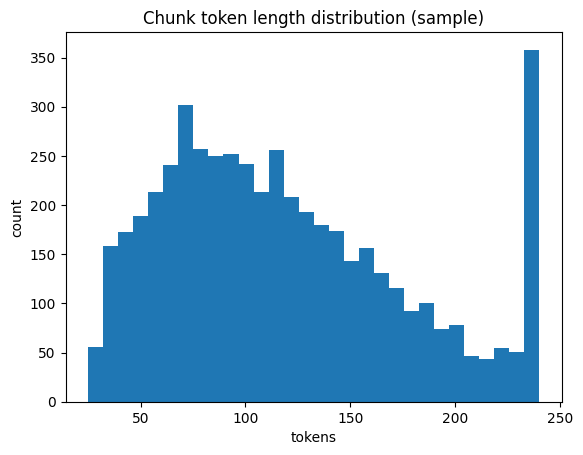

Avg tokens: 119.1228 | 95th pct: 240.0


In [10]:
import matplotlib.pyplot as plt

lens = [rec["n_tokens"] for rec in chunk_records[:5000]]  # sample for speed
plt.hist(lens, bins=30)
plt.title("Chunk token length distribution (sample)")
plt.xlabel("tokens"); plt.ylabel("count")
plt.show()

print("Avg tokens:", np.mean(lens), "| 95th pct:", np.percentile(lens, 95))


## Data Card (SQuAD v1.1)

- **Source:** SQuAD v1.1 (train + dev)
- **Docs:** Context paragraphs treated as documents (deduplicated)
- **Preprocessing:** whitespace normalization; token-aware chunking (max 240 tokens, stride 60)
- **Artifacts:**
  - `data/processed/squad_chunks.jsonl` — full processed chunks (git-ignored)
  - `data/sample/squad_chunks_sample.jsonl` — 200-chunk sample (committed)
  - `data/sample/squad_questions_sample.jsonl` — 100-question sample (committed)
- **Use:** The chunks feed the embedding + vector store stage; sample files enable quick demo & CI.